# Video Object Detection

This notebook extends the initial image-based YOLO baseline
to video input.

## Objectives

- Run YOLO detection on video frames
- Visualize detected objects
- Measure processing performance
- Save the detection result as an output video

This is the second stage of the
**Real-Time Object Detection & Tracking** project.

## 1. Setup

The video pipeline consists of:

Video
  ↓
Frame
  ↓
YOLO Detection
  ↓
Bounding Boxes
  ↓
Visualization

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 8.7 MB/s eta 0:00:00


In [2]:
import cv2
import time
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
model = YOLO("yolo11n.pt")

## 2. Load Video

We use a local video file as the input source.

The video will be processed frame by frame.

In [5]:
video_path = "/content/15956736_640_360_60fps.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Could not open video")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = frame_count / fps if fps > 0 else 0

print("FPS:", fps)
print("Resolution:", width, "x", height)
print("Frames:", frame_count)
print("Duration:", f"{duration:.2f} seconds")

FPS: 59.94005994005994
Resolution: 640 x 360
Frames: 250
Duration: 4.17 seconds


In [6]:
ret, frame = cap.read()

if not ret:
    raise RuntimeError("Could not read frame")

print("Frame shape:", frame.shape)

Frame shape: (360, 640, 3)



0: 384x640 2 persons, 4 cars, 44.8ms
Speed: 103.4ms preprocess, 44.8ms inference, 102.4ms postprocess per image at shape (1, 3, 384, 640)


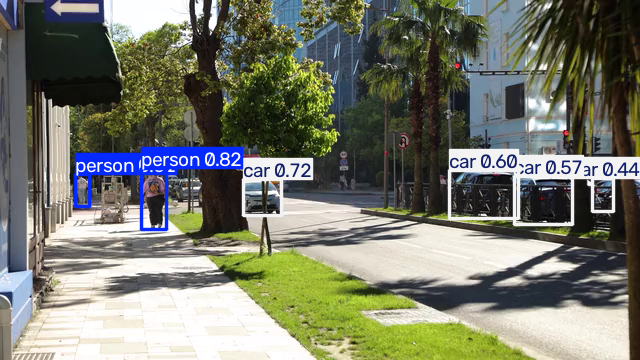

In [7]:
results = model(frame)

results[0].show()

## 3. Frame-by-Frame Detection

Each frame is passed through the YOLO detector.

For the first version of the pipeline, we use the model's
default post-processing and visualization.

In [8]:
output_path = "/content/output_detection.mp4"

cap = cv2.VideoCapture(video_path)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

In [9]:
frame_times = []
processed_frames = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    start_time = time.perf_counter()

    results = model(frame, verbose=False)

    annotated_frame = results[0].plot()

    elapsed = time.perf_counter() - start_time

    frame_times.append(elapsed)

    out.write(annotated_frame)

    processed_frames += 1

cap.release()
out.release()

print("Processed frames:", processed_frames)

Processed frames: 250


## 4. Performance

For a real-time system, processing speed is an important metric.

We measure:

- Average inference time per frame
- Approximate processing FPS

In [10]:
import numpy as np

average_frame_time = np.mean(frame_times)

processing_fps = 1 / average_frame_time

print(
    f"Average processing time: "
    f"{average_frame_time * 1000:.2f} ms/frame"
)

print(
    f"Processing FPS: "
    f"{processing_fps:.2f}"
)

Average processing time: 13.48 ms/frame
Processing FPS: 74.18


In [11]:
print(f"Source video FPS: {fps:.2f}")
print(f"Processing FPS: {processing_fps:.2f}")

if processing_fps >= fps:
    print("The detector can process frames at or above the source FPS.")
else:
    print("The detector is slower than the source video FPS.")

Source video FPS: 59.94
Processing FPS: 74.18
The detector can process frames at or above the source FPS.


## 5. Output

The processed video is saved as:

`output_detection.mp4`

The output contains the original frames with YOLO
detections overlaid.

In [12]:
from IPython.display import Video

Video(output_path, embed=True)

## 6. Findings

The image-based detection baseline was successfully extended
to video input.

### Observations

- YOLO can process video by running detection on individual frames.
- Each frame produces a new set of detections.
- Detection speed depends on model size, input resolution,
  hardware and scene complexity.
- Processing FPS and source video FPS are different measurements.

### Current Limitation

The current pipeline treats each frame independently.

The detector does not know whether an object detected in the
current frame is the same object detected in the previous frame.

This motivates the next stage:

**Object Tracking**